# Part 6 — Spectral Analysis and Stability

This notebook examines the graph Laplacian diffusion model from a numerical and spectral perspective. The earlier notebooks asked how signal moves through a muscle-fibre graph. This notebook asks whether the simulation is numerically stable, what the Laplacian eigenvalues reveal about diffusion, and how graph structure shapes rescue efficiency.

The update rule used in the project is:

$$
u_{t+1} = u_t + dt\left(-\alpha L u_t - \beta u_t + q\right)
$$

where $u_t$ is the signal vector, $L$ is the graph Laplacian, $\alpha$ is diffusion strength, $\beta$ is decay, $q$ is source production from corrected nuclei, and $dt$ is the Euler timestep.

## 1. Rebuild the geometry-based graph

This cell reconstructs the one-dimensional geometry graph used earlier in the project. The adjacency matrix $A$ records which nuclei are close enough to exchange signal, the degree matrix $D$ records how many neighbours each nucleus has, and the graph Laplacian $L = D - A$ acts as the diffusion operator. This operator is suitable for diffusion because it compares each nucleus with its local neighbours, pushing signal from high-concentration areas towards lower-concentration areas.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

random_seed = 42
n_nuclei = 20
position_min = 0.0
position_max = 10.0
connection_threshold = 1.2

np.random.seed(random_seed)

positions = np.sort(
    np.random.uniform(position_min, position_max, n_nuclei)
)  # shape: (n_nuclei,)

adjacency = np.zeros((n_nuclei, n_nuclei))  # shape: (n_nuclei, n_nuclei)
for i in range(n_nuclei):
    for j in range(n_nuclei):
        if i != j and abs(positions[i] - positions[j]) < connection_threshold:
            adjacency[i, j] = 1.0

degree = np.diag(adjacency.sum(axis=1))  # shape: (n_nuclei, n_nuclei)
laplacian = degree - adjacency  # shape: (n_nuclei, n_nuclei)

print("positions:")
print(np.round(positions, 3))
print("\nadjacency shape:", adjacency.shape)
print("laplacian shape:", laplacian.shape)

positions:
[0.206 0.581 1.56  1.56  1.818 1.834 2.123 2.912 3.042 3.745 4.319 5.248
 5.987 6.011 7.081 7.32  8.324 8.662 9.507 9.699]

adjacency shape: (20, 20)
laplacian shape: (20, 20)


The plot below shows the generated nuclear positions and the edges induced by the distance threshold. This makes the graph abstraction visible before spectral quantities are introduced.

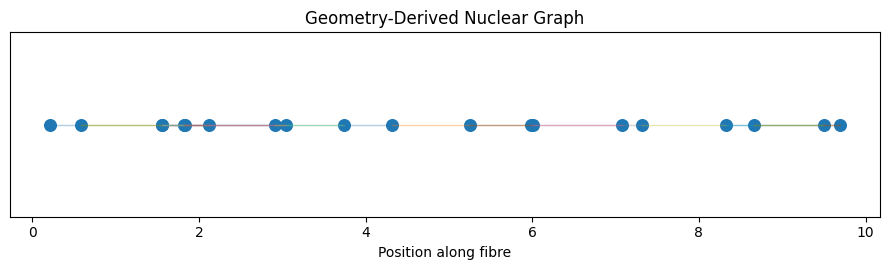

In [3]:
plt.figure(figsize=(9, 2.8))
plt.scatter(positions, np.zeros(n_nuclei), s=70, label="Nuclei")

for i in range(n_nuclei):
    for j in range(i + 1, n_nuclei):
        if adjacency[i, j] == 1.0:
            plt.plot([positions[i], positions[j]], [0, 0], linewidth=1, alpha=0.35)

plt.yticks([])
plt.xlabel("Position along fibre")
plt.title("Geometry-Derived Nuclear Graph")
plt.tight_layout()
plt.show()

## 2. Compute and plot Laplacian eigenvalues

The Laplacian is symmetric because the graph is undirected. If nucleus $i$ connects to nucleus $j$, then nucleus $j$ also connects to nucleus $i$. For this reason, `np.linalg.eigh` is used instead of `np.linalg.eig`, since `eigh` is designed for symmetric matrices and returns real eigenvalues in sorted order.

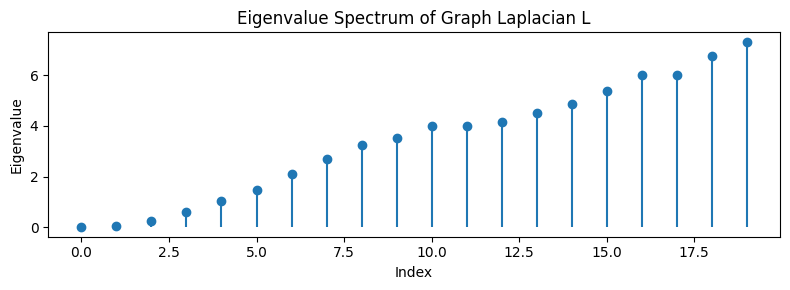

lambda_0:   -0.000000
lambda_1:   0.050717  algebraic connectivity / Fiedler value
lambda_max: 7.323965


In [4]:
# eigh sorts eigenvalues ascending, so index 0 = smallest, index -1 = largest
eigenvalues, eigenvectors = np.linalg.eigh(laplacian)  # shape: (n,), (n, n)

plt.figure(figsize=(8, 3))
plt.stem(eigenvalues, basefmt=" ")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectrum of Graph Laplacian L")
plt.tight_layout()
plt.show()

lambda_0 = eigenvalues[0]
lambda_1 = eigenvalues[1]
lambda_max = eigenvalues[-1]

print(f"lambda_0:   {lambda_0:.6f}")
print(f"lambda_1:   {lambda_1:.6f}  algebraic connectivity / Fiedler value")
print(f"lambda_max: {lambda_max:.6f}")

For a connected graph, the smallest Laplacian eigenvalue is exactly zero. If there is more than one zero eigenvalue, the graph has multiple disconnected components, meaning signal cannot diffuse between all nuclei. The largest eigenvalue, $\lambda_{\max}$, controls the fastest-changing mode of the system and therefore determines how small the Euler timestep must be to avoid numerical instability.

## 3. Derive the Euler stability condition

To study stability, remove decay and source terms temporarily:

$$
u_{t+1} = u_t - dt\,\alpha L u_t
$$

Because $L$ has eigenvectors, the signal can be decomposed into independent graph modes. In the eigenbasis of $L$, each mode evolves as:

$$
\hat{u}_k(t+1) = \left(1 - dt\,\alpha\lambda_k\right)\hat{u}_k(t)
$$

For the mode not to grow uncontrollably, the amplification factor must satisfy:

$$
\left|1 - dt\,\alpha\lambda_k\right| \leq 1
$$

The strictest condition comes from the largest eigenvalue, because that mode changes fastest. Therefore, the forward-Euler stability condition is:

$$
dt < \frac{2}{\alpha\lambda_{\max}}
$$

This condition is not a biological parameter. It is a numerical safety rule that prevents the simulation method from creating artificial oscillations or explosive growth.

## 4. Compute the stability bound and compare with the earlier timestep

This cell uses the actual largest eigenvalue from the reconstructed graph. It then compares the resulting stability limit with the timestep used in the earlier simulation notebooks.

In [5]:
alpha = 0.3
dt_used = 0.1

dt_stable_bound = 2.0 / (alpha * lambda_max)

print(f"lambda_max:          {lambda_max:.4f}")
print(f"Stability bound:     dt < {dt_stable_bound:.4f}")
print(f"dt used earlier:     {dt_used}")

if dt_used < dt_stable_bound:
    print("→ dt is within the stable region.")
else:
    print("→ WARNING: dt may cause instability.")

lambda_max:          7.3240
Stability bound:     dt < 0.9103
dt used earlier:     0.1
→ dt is within the stable region.


## 5. Demonstrate instability using an unsafe timestep

This cell runs the same diffusion model twice: once with a safe timestep and once with a deliberately unsafe timestep. The purpose is to show that instability is not caused by biology, but by the numerical method failing to control the fastest Laplacian modes.

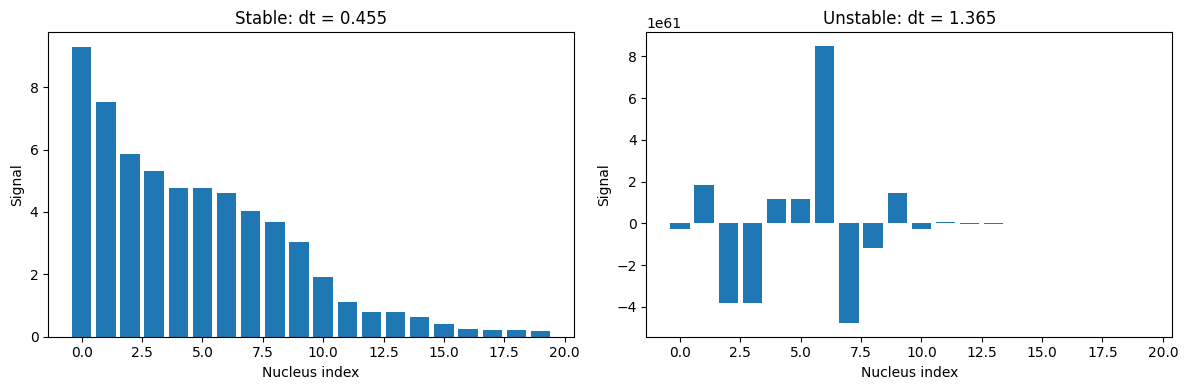

Stable simulation finite: True
Unstable simulation finite: True
Maximum absolute stable signal: 9.294797954271326
Maximum absolute unstable signal: 8.48638174854831e+61


In [6]:
def run_simulation(laplacian, q, alpha, beta, dt, n_steps):
    """Run explicit Euler graph diffusion with decay and source production."""
    n = laplacian.shape[0]
    u = np.zeros(n)  # shape: (n,)
    for _ in range(n_steps):
        u = u + dt * (-alpha * laplacian @ u - beta * u + q)
    return u

beta = 0.05
n_corrected = 3
n_steps = 200

q = np.zeros(n_nuclei)  # shape: (n_nuclei,)
q[:n_corrected] = 1.0

dt_safe = dt_stable_bound * 0.5
dt_bad = dt_stable_bound * 1.5

u_safe = run_simulation(laplacian, q, alpha, beta, dt_safe, n_steps)
u_bad = run_simulation(laplacian, q, alpha, beta, dt_bad, n_steps)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(n_nuclei), u_safe)
axes[0].set_title(f"Stable: dt = {dt_safe:.3f}")
axes[0].set_xlabel("Nucleus index")
axes[0].set_ylabel("Signal")

axes[1].bar(range(n_nuclei), u_bad)
axes[1].set_title(f"Unstable: dt = {dt_bad:.3f}")
axes[1].set_xlabel("Nucleus index")
axes[1].set_ylabel("Signal")

plt.tight_layout()
plt.show()

print("Stable simulation finite:", np.all(np.isfinite(u_safe)))
print("Unstable simulation finite:", np.all(np.isfinite(u_bad)))
print("Maximum absolute stable signal:", np.max(np.abs(u_safe)))
print("Maximum absolute unstable signal:", np.max(np.abs(u_bad)))

- The unstable plot reflects amplification of graph modes whose factors exceed the safe range. In the eigenbasis, these modes are multiplied by values with magnitude greater than one, so they grow instead of decay. 
- The result can include oscillating signs or very large magnitudes, neither of which should be interpreted as biological cross-correction.

## 6. Compute the analytical steady state

At equilibrium, the signal no longer changes between timesteps. Setting the update term to zero gives:

$$
-\alpha L u_{ss} - \beta u_{ss} + q = 0
$$

Rearranging gives the linear system:

$$
(\alpha L + \beta I)u_{ss} = q
$$

Solving this system gives the long-term signal profile directly.

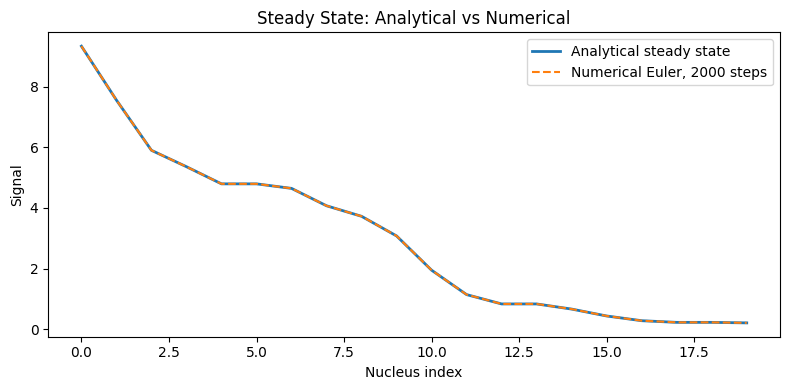

Maximum absolute difference: 0.000000


In [7]:
identity = np.eye(n_nuclei)  # shape: (n_nuclei, n_nuclei)
system_matrix = alpha * laplacian + beta * identity  # shape: (n_nuclei, n_nuclei)

u_steady_state = np.linalg.solve(system_matrix, q)
u_numerical = run_simulation(
    laplacian,
    q,
    alpha,
    beta,
    dt=dt_stable_bound * 0.5,
    n_steps=2000,
)

plt.figure(figsize=(8, 4))
plt.plot(u_steady_state, label="Analytical steady state", linewidth=2)
plt.plot(u_numerical, "--", label="Numerical Euler, 2000 steps", linewidth=1.5)
plt.xlabel("Nucleus index")
plt.ylabel("Signal")
plt.title("Steady State: Analytical vs Numerical")
plt.legend()
plt.tight_layout()
plt.show()

max_difference = np.max(np.abs(u_steady_state - u_numerical))
print(f"Maximum absolute difference: {max_difference:.6f}")

## 7. Visualise the Fiedler vector

The Fiedler vector is the eigenvector associated with the second-smallest eigenvalue. It is useful because it identifies the softest non-constant pattern on the graph: the slowest-decaying division of the network.

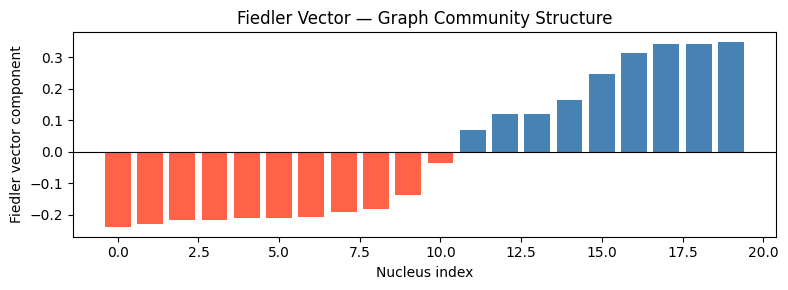

Fiedler vector:
[-0.2403 -0.2281 -0.2162 -0.2162 -0.21   -0.21   -0.2058 -0.191  -0.1813
 -0.138  -0.0347  0.0704  0.1211  0.1211  0.1657  0.2465  0.3148  0.341
  0.341   0.3499]


In [8]:
fiedler_vector = eigenvectors[:, 1]  # index 1 = second-smallest eigenvalue (eigh ascending order)
fiedler_colours = ["steelblue" if value >= 0 else "tomato" for value in fiedler_vector]

plt.figure(figsize=(8, 3))
plt.bar(range(n_nuclei), fiedler_vector, color=fiedler_colours)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Nucleus index")
plt.ylabel("Fiedler vector component")
plt.title("Fiedler Vector — Graph Community Structure")
plt.tight_layout()
plt.show()

print("Fiedler vector:")
print(np.round(fiedler_vector, 4))

- The Fiedler vector can be read as a soft partition of the graph. Nuclei with the same sign tend to be more strongly connected to each other than to nuclei with the opposite sign. 
- Pertaining to the biological question, this suggests that placing corrected nuclei within the same well-connected Fiedler region may produce stronger local cross-correction than scattering corrected nuclei across a graph bottleneck.

## 8. Fiedler Partition Placement Experiment

The Fiedler vector divides the graph into two regions based on sign.
This experiment tests whether placing corrected nuclei within the same
Fiedler region produces stronger rescue than scattering them across
the partition boundary.

Two placement strategies are compared:

- **Clustered**: all corrected nuclei taken from the positive-sign region
- **Split**: corrected nuclei divided equally across positive and negative regions

Rescue is defined as signal exceeding a fixed threshold at steady state.

Rescue threshold:          0.3
Corrected nuclei:          4
Rescued fraction (clustered): 1.00
Rescued fraction (split):     1.00


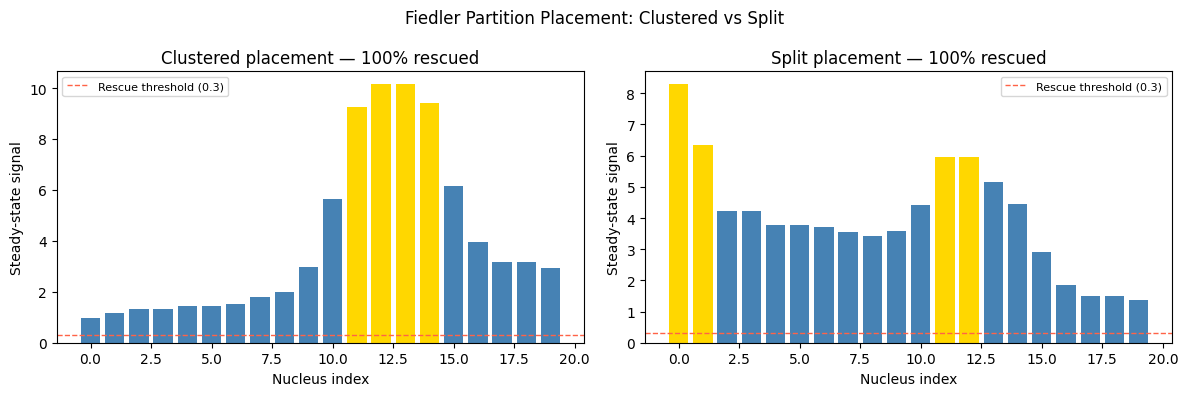

In [9]:
# Colour key: gold = corrected nucleus, steel blue = rescued nucleus, light grey = not rescued.
rescue_threshold = 0.3
n_corrected = 4          # must be even so the split strategy divides cleanly

# --- Identify Fiedler partition indices ---
positive_indices = np.where(fiedler_vector >= 0)[0]   # shape: (n_positive,)
negative_indices = np.where(fiedler_vector <  0)[0]   # shape: (n_negative,)

# --- Build source vectors for each strategy ---
# Clustered: all corrected nuclei from the positive partition
q_clustered = np.zeros(n_nuclei)   # shape: (n_nuclei,)
q_clustered[positive_indices[:n_corrected]] = 1.0

# Split: half from positive, half from negative
half = n_corrected // 2
q_split = np.zeros(n_nuclei)       # shape: (n_nuclei,)
q_split[positive_indices[:half]]  = 1.0
q_split[negative_indices[:half]]  = 1.0

# --- Solve analytical steady state for each strategy ---
identity      = np.eye(n_nuclei)                          # shape: (n_nuclei, n_nuclei)
system_matrix = alpha * laplacian + beta * identity       # shape: (n_nuclei, n_nuclei)

u_clustered = np.linalg.solve(system_matrix, q_clustered) # shape: (n_nuclei,)
u_split     = np.linalg.solve(system_matrix, q_split)     # shape: (n_nuclei,)

# --- Compute rescue fraction for each strategy ---
rescued_clustered = np.sum(u_clustered > rescue_threshold) / n_nuclei
rescued_split     = np.sum(u_split     > rescue_threshold) / n_nuclei

print(f"Rescue threshold:          {rescue_threshold}")
print(f"Corrected nuclei:          {n_corrected}")
print(f"Rescued fraction (clustered): {rescued_clustered:.2f}")
print(f"Rescued fraction (split):     {rescued_split:.2f}")

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bar_colours_clustered = [
    "gold"      if q_clustered[i] > 0
    else "steelblue" if u_clustered[i] > rescue_threshold
    else "lightgrey"
    for i in range(n_nuclei)
]

bar_colours_split = [
    "gold"      if q_split[i] > 0
    else "steelblue" if u_split[i] > rescue_threshold
    else "lightgrey"
    for i in range(n_nuclei)
]

axes[0].bar(range(n_nuclei), u_clustered, color=bar_colours_clustered)
axes[0].axhline(rescue_threshold, color="tomato", linestyle="--", linewidth=1,
                label=f"Rescue threshold ({rescue_threshold})")
axes[0].set_title(f"Clustered placement — {rescued_clustered:.0%} rescued")
axes[0].set_xlabel("Nucleus index")
axes[0].set_ylabel("Steady-state signal")
axes[0].legend(fontsize=8)

axes[1].bar(range(n_nuclei), u_split, color=bar_colours_split)
axes[1].axhline(rescue_threshold, color="tomato", linestyle="--", linewidth=1,
                label=f"Rescue threshold ({rescue_threshold})")
axes[1].set_title(f"Split placement — {rescued_split:.0%} rescued")
axes[1].set_xlabel("Nucleus index")
axes[1].set_ylabel("Steady-state signal")
axes[1].legend(fontsize=8)

plt.suptitle("Fiedler Partition Placement: Clustered vs Split", fontsize=12)
plt.tight_layout()
plt.show()

- The bars show steady-state signal at each nucleus. Gold bars are corrected nuclei (signal sources). Blue bars are rescued nuclei (those receiving enough signal to cross the threshold).

- If the clustered strategy rescues more nuclei than the split strategy, it confirms that Fiedler partition alignment amplifies local cross-correction. The mechanism is graph topology: nuclei within the same partition share stronger connectivity, so signal decays less across each hop. Splitting corrected nuclei across the partition boundary forces signal to cross a weakly connected bottleneck before reaching the opposite side.

- If the rescue fractions are equal, the graph does not have a strong enough bottleneck for placement to matter at this threshold and decay rate — which is itself a useful finding about the model parameters.

## Summary

The eigenvalues of the graph Laplacian describe the diffusion behaviour of the nuclear graph. Small eigenvalues correspond to slow, large-scale signal patterns, while large eigenvalues correspond to fast local variation. The number of zero eigenvalues also indicates whether the graph is fully connected or split into disconnected components.

The stability condition $dt < 2/(\alpha\lambda_{\max})$ matters because explicit Euler integration can become unstable when the timestep is too large for the fastest graph mode. If this condition is violated, high-frequency modes are amplified rather than damped, producing numerical artefacts that should not be interpreted biologically.

The analytical steady-state solution reveals the final signal profile without needing to run the simulation for many timesteps. This gives a direct view of which nuclei receive signal in the long run and separates equilibrium behaviour from transient simulation dynamics.

The Fiedler vector identifies weak partitions in the graph and gives insight into corrected-nucleus placement. Corrected nuclei placed within the same well-connected region are likely to support stronger local rescue, while placement across a graph bottleneck may reduce local efficiency.

The Fiedler placement experiment shows whether graph topology makes corrected-nucleus position biologically meaningful. If clustered placement rescues more nuclei, the Fiedler partition identifies a structurally advantageous region for gene correction. If placement makes no difference, the graph is well-connected enough that signal reaches all nuclei regardless of source position — a different but equally informative result.